# 파이썬 30회차 기출문제 해답


## 문제 1

**Data description**

개인의 건강 상태를 평가하기 위한 다양한 생물학적 및 생리학적 지표들을 포함하는 건강 검진 데이터입니다.

-   **Age**: 피검자의 나이

-   **Gender**: 피검자의 성별

-   **BMI**: 체질량 지수

-   **FPG**: 공복 시 혈당 수치

-   **Chol**: 혈중 총 콜레스테롤 수치

-   **Tri**: 혈중 트리글리세라이드 수치

-   **HDL**: 혈중 고밀도지단백 콜레스테롤 수치 (High-Density Lipoprotein Cholesterol)

-   **LDL**: 혈중 저밀도지단백 콜레스테롤 수치 (Low-Density Lipoprotein Cholesterol)

-   **ALT**: 간 효소 수치 중 하나로, 알라닌 아미노트랜스페라제 (Alanine Aminotransferase)

-   **DBP**: 이완기 혈압 수치 (Diastolic Blood Pressure)

In [51]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import koreanize_matplotlib

warnings.filterwarnings('ignore')

In [53]:
d1 = pd.read_csv('https://raw.githubusercontent.com/qiwerr1004/ADP_go/main/30/problem1.csv')
display(d1.info())
display(d1.head(3))

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4303 entries, 0 to 4302
Data columns (total 10 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Age     4303 non-null   int64  
 1   Gender  4303 non-null   int64  
 2   BMI     4303 non-null   float64
 3   DBP     4303 non-null   int64  
 4   FPG     4303 non-null   float64
 5   Chol    4302 non-null   float64
 6   Tri     4303 non-null   float64
 7   HDL     4303 non-null   float64
 8   LDL     4303 non-null   float64
 9   ALT     4303 non-null   float64
dtypes: float64(7), int64(3)
memory usage: 336.3 KB


None

,Age,Gender,BMI,DBP,FPG,Chol,Tri,HDL,LDL,ALT
0,26,1,20.1,81,5.8,4.36,0.86,0.90,2.43,12.0
1,40,1,17.7,54,4.6,3.70,1.02,1.50,2.04,9.2
2,40,2,19.7,53,5.3,5.87,1.29,1.75,3.37,10.1


1.  **EDA를 수행하시오.**

In [54]:
d1.isna().sum()[d1.isna().sum()>0]

Chol    1
dtype: int64

<<명목형 변수 통계량 및 시각화>>


,count,unique,top,freq
Gender,4303,2,1,2790


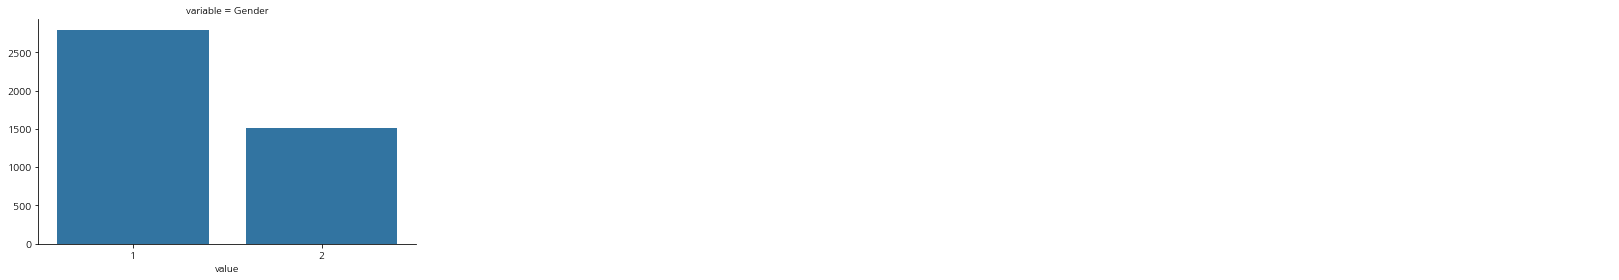

<<수치형 변수 통계량 및 시각화>>


,count,mean,std,min,25%,50%,75%,max
Age,4303.0,48.085057,14.686155,22.00,35.00,46.00,59.00,93.000000
BMI,4303.0,24.123923,3.397294,15.60,21.70,24.00,26.30,45.800000
DBP,4303.0,76.360446,11.004056,45.00,69.00,76.00,83.00,134.000000
FPG,4303.0,5.226368,0.781089,1.78,4.70,5.14,5.70,6.990000
Chol,4302.0,4.860732,0.925484,1.65,4.20,4.79,5.43,11.650000
Tri,4303.0,1.588476,1.260003,0.00,0.86,1.28,1.94,32.640000
HDL,4303.0,1.666765,1.079377,0.00,1.13,1.34,1.61,4.860753
LDL,4303.0,2.976220,0.892196,0.54,2.35,2.82,3.42,6.270000
ALT,4303.0,26.754810,22.279922,4.50,14.30,20.50,31.05,436.200000


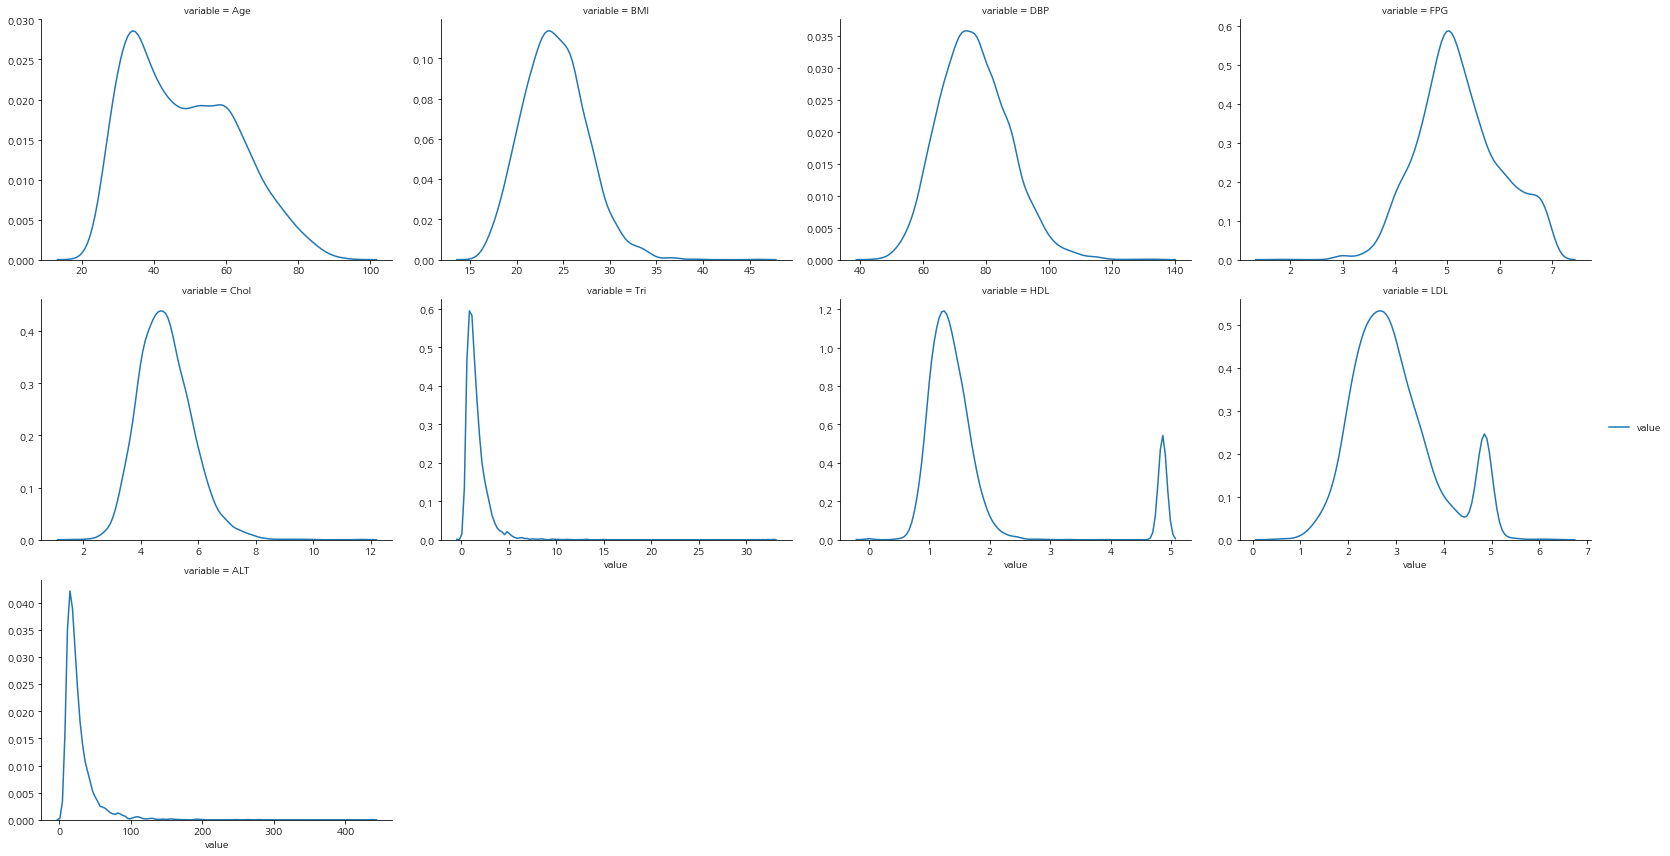

In [59]:
#명목형 변수 타입변환
d1['Gender'] = d1['Gender'].astype('O')

n_cols = d1.select_dtypes('number').columns
c_cols = d1.select_dtypes('O').columns

print("<<명목형 변수 통계량 및 시각화>>")
display(d1[c_cols].describe().T)
mt = d1.melt(value_vars=c_cols)
g = sns.FacetGrid(mt, col='variable', col_wrap=4, height=4, aspect=1.4, sharex=False, sharey=False)
g.map(sns.countplot, 'value')
g.add_legend()
plt.show()

print("<<수치형 변수 통계량 및 시각화>>")
display(d1[n_cols].describe().T)
mt = d1.melt(value_vars=n_cols)
g = sns.FacetGrid(mt, col='variable', col_wrap=4, height=4, aspect=1.4, sharex=False, sharey=False)
g.map(sns.kdeplot, 'value')
g.add_legend()
plt.show()

- 성별은 남성 비율이 다소 높음
- 높은 양의 왜도: tri, alt
- 이봉분포: Hdl, Ldl
- 정규분포에 가까움: BMI, DBP

In [64]:
# 연속형 변수에 대한 이상치 탐지
err = d1[n_cols].describe().T
q1 = err['25%']
q3 = err['75%']
iqr = q3 - q1
up = q3 + (1.5*iqr)
down = q1 = (1.5*iqr)

for col in up.index:
    er = d1[(d1[col] > up[col])|(d1[col] < down[col])]
    print(f"{col} 이상치 비율: {len(er)/len(d1)*100:.2f} %")

Age 이상치 비율: 25.96 %
BMI 이상치 비율: 0.95 %
DBP 이상치 비율: 1.19 %
FPG 이상치 비율: 0.00 %
Chol 이상치 비율: 1.42 %
Tri 이상치 비율: 69.88 %
HDL 이상치 비율: 10.71 %
LDL 이상치 비율: 3.00 %
ALT 이상치 비율: 70.76 %


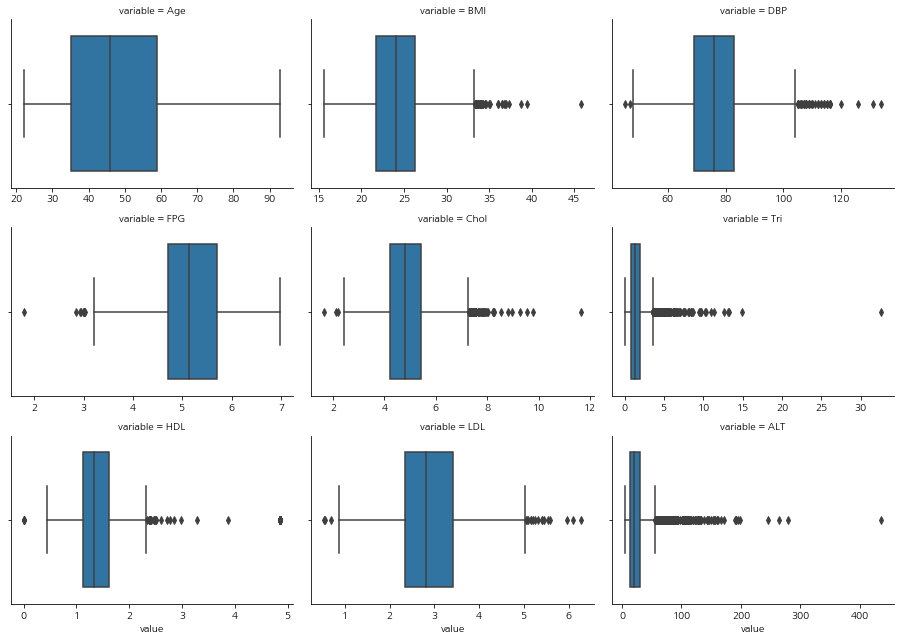

In [72]:
mt = d1.melt(value_vars=n_cols)
g = sns.FacetGrid(mt, col='variable', col_wrap=3, height=3, aspect=1.4, sharex=False, sharey=False)
g.map(sns.boxplot, 'value')
g.add_legend()
plt.show()

IQR 기준으로 상하단에 포함되지 않는 데이터가 식별되었는데, 해당 데이터에 대한 사전지식이 없으므로 이상치 여부를 판단할 수 없다.  
(이상치처럼 보이는 데이터도 실제 문제에서는 분류/회귀를 위한 특징정보일 수 있으므로)  
따라서 처리하지 않는다.

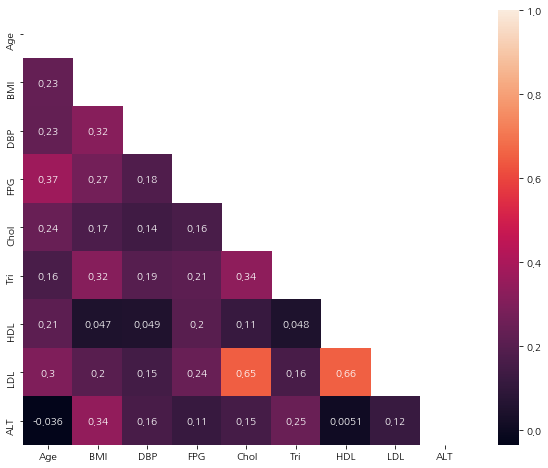

In [74]:
plt.figure(figsize=(10, 8))
corr = d1.corr()
mask = np.triu(np.ones_like(corr, dtype='bool'))
sns.heatmap(corr, mask=mask, annot=True)
plt.show()

콜레스테롤과 ldl, hdl-ldl간 0.6 이상의 양의 선형상관관계가 식별된다.   
추후 다중공선성 여부를 보다 정확히 확인하기 위해 vif를 확인한다.

#### 2.  데이터 전처리가 필요하다면 수행하고 이유를 작성하시오.


앞서 콜레스테롤 컬럼에서 1개의 결측치가 존재하는 것이 식별되었다.  
전체 데이터 대비 아주 적은 비율로 모델학습에 크게 영향을 주지 않으므로 삭제한다.(시간, 비용 고려)

In [73]:
d1 = d1.dropna()

#### 3.  train test set을 DBP 컬럼 기준으로 7:3 비율로 나눈 후 잘 나뉘었는지 통계적으로 나타내시오.

In [83]:
from sklearn.model_selection import train_test_split

x = d1.drop('DBP', axis=1)
y = d1['DBP']

x = pd.get_dummies(x, columns=['Gender'], drop_first=True)

train_x, test_x, train_y, test_y = train_test_split(x, y, test_size=0.3, random_state=42)

train_y.shape, test_y.shape

((3011,), (1291,))

두 데이터셋이 균형있게 나뉘었는지를 확인하기 위해 k-s test를 수행한다.  
k-s test는 두 데이터셋의 cdf(누적확률분포)의 동질성을 비교하는 방식의 통계기법이다.   
(유의수준 5% 하 검정)  
- 귀무가설: 두 데이터셋은 누적확률분포 차이가 없다. 
- 대립가설: 두 데이터셋은 누적확률분포 차이가 있다.

In [84]:
from scipy.stats import ks_2samp

stat, p = ks_2samp(train_y, test_y)

print(f"k-s test 통계량: {stat:.3f}")
print(f"pvalue: {p:.3f}, 귀무가설", "기각" if p < 0.05 else "기각불가")

k-s test 통계량: 0.017
pvalue: 0.961, 귀무가설 기각불가


k-s 테스트 결과, pvalue: 0.961이므로 귀무가설을 기각할 수 없다. 따라서 두 데이터셋은 누적확률분포 차이가 없다.이므로  
통계적으로 잘 나뉘었다. 

#### 4. 독립변수의 차원축소의 필요성을 논하고, 필요에 따라 차원을 축소하고 불필요하다면 그 근거를 논하시오.


In [108]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

n_cols = train_x.select_dtypes('number').columns[:-1]

def check_vif(dt, cols):
    vif = pd.DataFrame()
    vif['name'] = cols
    vif['vif'] = [variance_inflation_factor(dt[cols].values, i) for i in range(len(cols))]
    display(vif)
    
check_vif(train_x, n_cols)

,name,vif
0,Age,15.139367
1,BMI,43.814453
2,FPG,44.781489
3,Chol,59.192139
4,Tri,2.943770
5,HDL,8.752220
6,LDL,51.639481
7,ALT,2.707848


vif 결과, 10 이상의 독립변수가 다수 식별되었다.(BMI: 43.814453 등) 이는 독립변수 간 중복되는 정보가 상당부분 존재하는    
(독립변수들 간 강한 상관관계가 있는) 다중공선성이 있음을 의미한다.    
다중공선성이 존재하면, 1. 회귀계수 추정 불안정, 2. 표준 오차 과대평가, 3. 모델 성능 저하, 4. 변수 선택 어려움, 5. 해석 모호  
의 문제가 생기므로 차원축소(PCA)를 통해 다중공선성 문제를 제거한다. 

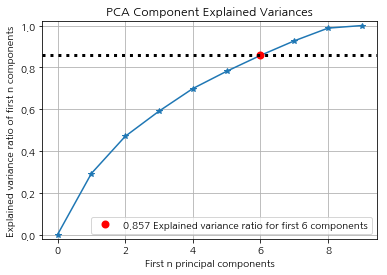

(3011, 6)


,name,vif
0,1,1.0
1,2,1.0
2,3,1.0
3,4,1.0
4,5,1.0
5,6,1.0


In [118]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.compose import make_column_transformer
from sklearn.pipeline import Pipeline
from scikitplot.decomposition import plot_pca_component_variance


precessor = Pipeline([
    ('scaler', StandardScaler()), 
    ('pca', PCA())
])

precessor.fit_transform(train_x)

plot_pca_component_variance(precessor.named_steps['pca'], target_explained_variance=0.8)
plt.show()

precessor2 = Pipeline([
    ('scaler', StandardScaler()), 
    ('pca', PCA(n_components=0.8))
])

tx = pd.DataFrame(precessor2.fit_transform(train_x), columns=np.arange(1, 7))

check_vif(tx, np.arange(1, 7))

PCA를 적용하여 원 데이터 분산의 0.857%를 설명하는 7개의 주성분축으로 차원을 축소하였다.  
이를 통해 각 설명변수들 간 다중공선성이 제거되었다. 

#### 5.  데이터가 회귀분석의 기본가정 따르는지 설명하시오.


- 회귀분석은 기본적으로 잔차의 기본가정을 만족해야만 모델결과의 신뢰성이 보장된다.  

1. 선형성: 독립변수와 종속변수 간 선형관계(잔차-예측값 산점도 상 고르게 분포, 패턴 없음)
2. 정규성: 잔차가 정규분포를 따름(shapiro 검정)
3. 등분산성: 잔차 분산이 동일(잔차 산점도 및 breusch-pagan검정)
4. 독립성: 잔차들이 서로 독립(durbin-watshon 검정에서 2에 가까움: 1.5~2.5)

In [121]:
#먼저 모델 적합
import statsmodels.api as sm

x = sm.add_constant(train_x)

lin1 = sm.OLS(train_y, x).fit()

print(lin1.summary())

                            OLS Regression Results                            
Dep. Variable:                    DBP   R-squared:                       0.149
Model:                            OLS   Adj. R-squared:                  0.146
Method:                 Least Squares   F-statistic:                     58.23
Date:                Sat, 27 Sep 2025   Prob (F-statistic):           1.89e-98
Time:                        15:32:25   Log-Likelihood:                -11274.
No. Observations:                3011   AIC:                         2.257e+04
Df Residuals:                    3001   BIC:                         2.263e+04
Df Model:                           9                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         50.1643      1.973     25.431      0.0

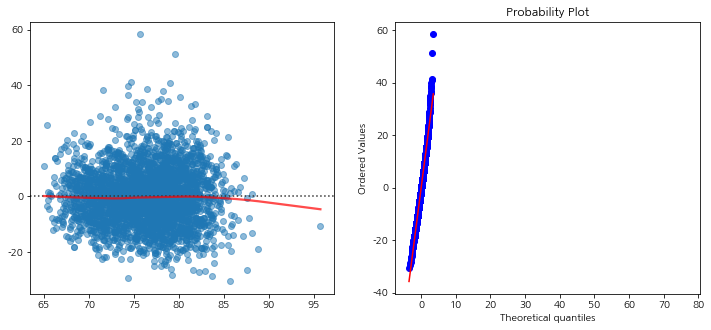

shapiro pvalue: 0.000 / 정규성  불만족
het_breuschpagan pvalue: 0.000 / 등분산성  불만족
더빈왓슨 검정결과: 2.018 / 자기상관 만족


In [139]:
# 모델의 잔차 검정

resid = lin1.resid
fitted = lin1.fittedvalues

from scipy.stats import shapiro, levene, probplot
from statsmodels.graphics.gofplots import qqplot
from statsmodels.stats.diagnostic import het_breuschpagan
from statsmodels.stats.stattools import durbin_watson

fig, ax = plt.subplots(1, 2, figsize=(12, 5))
#1. 선형성, 등분산성 확인
sns.residplot(fitted, resid, lowess=True, 
             scatter_kws={'alpha': 0.5}, 
             line_kws={'color': 'r', 'alpha': 0.7}, ax=ax[0])

#QQplot: 정규성 확인
probplot(resid, dist='norm', plot=ax[1], fit=True)
plt.show()

# shapiro: 정규성 확인
stat, p = shapiro(resid)
print(f"shapiro pvalue: {p:.3f} / 정규성 ", "만족" if p >= 0.05 else "불만족")

#het_breuschpagan: 등분산성 확인
stat, p, _, _ = het_breuschpagan(resid, lin1.model.exog)
print(f"het_breuschpagan pvalue: {p:.3f} / 등분산성 ", "만족" if p >= 0.05 else "불만족")

#자기상관: 더빈왓슨 검정
dw = durbin_watson(resid)
print(f"더빈왓슨 검정결과: {dw:.3f} / 자기상관 " "만족" if (dw>=1.5) | (dw <=2.5) else "불만족")

- 선형성: 잔차가 뭉쳐있으므로 선형성 만족하지 않음
- 정규성: 불만족(shapiro, qqplot)
- 등분산성: 불만족(het_breuschpagan)
- 독립성: 만족(더빈왓슨 검정결과가 2에 가까우므로 )

### 6. 회귀분석 알고리즘 3개를 선택하고 선정이유와 장단점을 비교하시오.

위에서 3가지(선형성, 정규성, 등분산성) 가정을 만족하지 않으므로 일반적인 회귀모델은 적절치 않다.  
따라서 트리기반이나 이상치나 이분산에 강건한 모델을 선정한다. 

1. 랜덤포레스트 회귀: 배깅기반 앙상블 트리 모형으로 여러 결정 트리를 평균 내어 예측. 이상치와 비선형 관계 모두에 강건,  
   데이터 분포나 오차분포에 대한 가정을 거의 하지 않으며, 트리기반으로 비선형관계까지 포착가능
   - 단점: 데이터가 많을 시 계산비용 높음, 해석성 부족
2. 로버스트 회귀(Huber 회귀): 작은 오차는 제곱 오차, 큰 오차는 절댓값 오차로 처리해 이상치 영향 완화, 유연한 임계값 설정
   - 단점: 임계값 선택 민감, 이상치가 많을 시 한계, 다중공선성, 비선형성 해결불가 
3. 인공신경망 회귀: 딥러닝 모델로 통계가정이 불필요하며, 활성화 함수로 비선형 관계 학습이 가능함, 
   - 단점: 충분한 데이터, 하이퍼파라미터 최적화, 과적합 방지 방식(드롭아웃, 정규화)이 보장되어야 함

In [142]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.linear_model import HuberRegressor
from sklearn.metrics import r2_score, mean_squared_error

rf = Pipeline([
    ('precessor', precessor2), 
    ('rg', RandomForestRegressor(random_state=42))
])

huber = Pipeline([
    ('precessor', precessor2), 
    ('rg', HuberRegressor())
])
mlp = Pipeline([
    ('precessor', precessor2), 
    ('rg', MLPRegressor(random_state=42))
])

m_list = [("random forest rg", rf), ('huber rg', huber), ('mlp rg', mlp)]
d_list = [('train', train_x, train_y), ('test', test_x, test_y)]

rs = pd.DataFrame(columns=['model', 'data', 'r2', 'rmse'])

for m1, model in m_list:
    model.fit(train_x, train_y)
    for m2, x, y in d_list:
        pred = model.predict(x)
        r2 = r2_score(y, pred)
        rmse = np.sqrt(mean_squared_error(y, pred))
        rs.loc[len(rs)] = [m1, m2, r2, rmse]
display(rs)

,model,data,r2,rmse
0,random forest rg,train,0.872484,3.959068
1,random forest rg,test,0.122970,10.119585
2,huber rg,train,0.139999,10.281577
3,huber rg,test,0.156930,9.921730
4,mlp rg,train,0.087709,10.589536
5,mlp rg,test,0.037882,10.599117


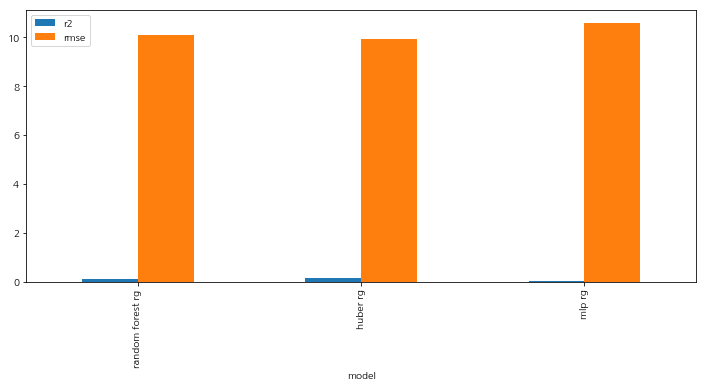

In [143]:
tmp = rs[rs['data'] == 'test'].drop(columns=['data'])
tmp = tmp.set_index('model')
ax = tmp.plot(kind='bar', figsize=(12, 5))
plt.show()

로버스트 회귀모델인 huber의 성능이 세 모델 대비 가장 뛰어난 것을 알 수 있다.   
huber rg	r2: 0.156930	rmse: 9.921730

## 문제 2

**Data description**

교통사고와 관련된 다양한 정보들을 포함하는 사고 기록 데이터입니다.

-   **사고내용**: 사고가 발생한 상황에 대한 설명

-   **가해자성별**: 사고를 일으킨 가해자의 성별

-   **가해자연령**: 사고를 일으킨 가해자의 연령

-   **가해자차종**: 가해자가 운전한 차량의 종류

-   **피해자신체상해정도**: 사고로 인해 피해자가 입은 신체 상해의 정도

-   **사고유형**: 사고의 유형 (예: 추돌, 전복, 충돌 등)

-   **기상상태**: 사고 발생 당시의 기상 상태 (예: 맑음, 비, 눈 등)

-   **사망자수**: 사고로 인한 사망자 수

-   **발생시각**: 사고가 발생한 시간


In [152]:
d2 = pd.read_csv('https://raw.githubusercontent.com/qiwerr1004/ADP_go/main/30/problem2.csv')
print(d2.info())
d2.head(2)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2410 entries, 0 to 2409
Data columns (total 9 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   사고내용       2410 non-null   object
 1   가해자성별      2400 non-null   object
 2   가해자연령      2406 non-null   object
 3   가해자차종      2410 non-null   object
 4   피해자신체상해정도  2410 non-null   object
 5   사고유형       2410 non-null   object
 6   기상상태       2410 non-null   object
 7   사망자수       2410 non-null   int64 
 8   발생시각       2410 non-null   object
dtypes: int64(1), object(8)
memory usage: 169.6+ KB
None


,사고내용,가해자성별,가해자연령,가해자차종,피해자신체상해정도,사고유형,기상상태,사망자수,발생시각
0,경상,여,75세,자전거,경상,차대차 - 기타,맑음,0,2018-04-03 15시
1,중상,여,26세,자전거,중상,차대차 - 측면충돌,맑음,0,2018-04-21 13시


## 1.  평일/주말을 구분하는 ‘주말여부’ 변수를 추가하고 데이터 분포를 확인하시오.

발생시각 -> 발생일자, 발생시각 -> 발생일자를 통해 요일을 확인한 후 주말여부 변수를 추가

In [153]:
d2 = d2.dropna()

In [154]:
d2['발생시각'] = pd.to_datetime(d2['발생시각'], format='%Y-%m-%d %H시')
#0:월요일, 6:일요일
d2['발생요일'] = d2['발생시각'].dt.weekday
d2['주말여부'] = np.where(d2['발생요일'].isin([5, 6]), 1, 0)
d2 = d2.drop(columns=['발생요일'])
display(d2.head())

,사고내용,가해자성별,가해자연령,가해자차종,피해자신체상해정도,사고유형,기상상태,사망자수,발생시각,주말여부
0,경상,여,75세,자전거,경상,차대차 - 기타,맑음,0,2018-04-03 15:00:00,0
1,중상,여,26세,자전거,중상,차대차 - 측면충돌,맑음,0,2018-04-21 13:00:00,1
2,중상,남,34세,자전거,중상,차대차 - 기타,맑음,0,2018-05-01 08:00:00,0
3,경상,남,45세,자전거,경상,차대차 - 기타,맑음,0,2018-06-03 18:00:00,1
4,중상,남,20세,자전거,중상,차대차 - 측면충돌,맑음,0,2018-06-28 16:00:00,0


## 2.  주말여부에 따라 각 변수들(사고내용, 가해자성별, 가해자연령, 기상상태, 사고유형)이 통계적으로 유의한지 검정하시오.

주말여부는 이진 명복형 변수이며, 각 변수들의 특성에 따라 다음과 같이 검정한다. 

- 수치형 변수: 정규성 만족 시 독립검정 ttest(등분산성 불만족 시 welch's), 불만족시 맨위트니 u 검정
- 명목형 변수: 카이제곱 독립성 검정(비모수검정)

유의수준 5% 하 가설검정수행  
- 귀무가설: 주말여부에 따라 각 변수들은 통계적으로 유의하지 않다.(독립)
- 대립가설: 주말여부에 따라 각 변수들은 통계적으로 유의하다.(연관)

In [185]:
n_cols = ['가해자연령']
c_cols = ['사고내용', '가해자성별', '기상상태', '사고유형']

# d2['가해자연령'] = d2['가해자연령'].str.replace('세', '').astype('int64')

from scipy.stats import shapiro, mannwhitneyu

gr = [g[n_cols] for name, g in d2.groupby('주말여부')]
for i, g in enumerate(gr):
    stat, p = shapiro(g)
    print(f"{i} 그룹 정규성 만족여부({p:.3f}) / 정규성 ", "만족" if p >= 0.05 else "불만족")
    
stat, p = mannwhitneyu(*gr)
print(f"맨휘트니 u 검정결과({p[0]:.3f}) / 통계적 유의: ", "만족" if p < 0.05 else "불만족")

0 그룹 정규성 만족여부(0.000) / 정규성  불만족
1 그룹 정규성 만족여부(0.000) / 정규성  불만족
맨휘트니 u 검정결과(0.249) / 통계적 유의:  불만족


In [186]:
from scipy.stats import chi2_contingency

for col in c_cols:
    cr = pd.crosstab(d2[col], d2['주말여부'])
    stat, p, ddof, expected = chi2_contingency(cr)
    print(f"- {col}: 카이제곱 독립성 검정결과({p:.3f})/ 통계적 유의: ", "만족" if p < 0.05 else "불만족")

- 사고내용: 카이제곱 독립성 검정결과(0.051)/ 통계적 유의:  불만족
- 가해자성별: 카이제곱 독립성 검정결과(0.001)/ 통계적 유의:  만족
- 기상상태: 카이제곱 독립성 검정결과(0.057)/ 통계적 유의:  불만족
- 사고유형: 카이제곱 독립성 검정결과(0.704)/ 통계적 유의:  불만족


가해자 성별을 제외한 사고내용, 가해자연령, 기상상태, 사고유형은 통계적으로 유의하지 않다.  
따라서 가해자 성별은 종속변수 클래스를 분류할 수 있는 특징정보가 유의함을 뜻하고,  
나머지 변수들은 두 클래스로 분류한 데이터의 분포가 비슷함(특징정보가 모호함)을 뜻한다.

## 3. SMOTE 오버샘플링하고 변수별 빈도를 나타내고 연속형변수의 경우 평균을 구하시오.

SMOTE 샘플링은 훈련 데이터에만 적용되어야 하므로, 먼저 전체 데이터를 훈련 세트와 테스트 세트로 분할한다.  
분할 시에는 주말여부 칼럼이 클래스 불균형을 보이므로, 층화 샘플링(stratified sampling) 을 적용하여 각 클래스 비율이 유지되도록 한다.


In [211]:
from imblearn.over_sampling import SMOTENC
from sklearn.compose import make_column_transformer
from imblearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
from collections import Counter

x = d2.drop(columns=['발생시각', '주말여부'])
y = d2['주말여부']

train_x, test_x, train_y, test_y = train_test_split(x, y, random_state=42)

sm = SMOTENC(categorical_features=[0, 1, 3, 4, 5, 6], random_state=42)

train_x2, train_y2 = sm.fit_resample(train_x, train_y)

print(f"{Counter(train_y2)}")

Counter({0: 1358, 1: 1358})


In [212]:
train_x = pd.DataFrame(train_x2, columns=train_x.columns)

train_x[['가해자연령', '사망자수']] = train_x[['가해자연령', '사망자수']].astype('int64')

n_cols = train_x.select_dtypes('number').columns
c_cols = train_x.select_dtypes('O').columns

for col in c_cols:
    print(f"- {col} 컬럼 빈도수")
    display(train_x[col].value_counts().reset_index())
for col in n_cols:
    print(f"- {col} 컬럼 평균: {train_x[col].mean()}")

- 사고내용 컬럼 빈도수


,index,사고내용
0,경상,1572
1,중상,1144


- 가해자성별 컬럼 빈도수


,index,가해자성별
0,남,2087
1,여,629


- 가해자차종 컬럼 빈도수


...

- 사고유형 컬럼 빈도수


,index,사고유형
0,차대차 - 측면충돌,1514
1,차대차 - 기타,990
2,차대사람 - 기타,126
3,차대차 - 추돌,86


- 기상상태 컬럼 빈도수


,index,기상상태
0,맑음,2628
1,흐림,44
2,비,44


- 가해자연령 컬럼 평균: 49.08136966126657
- 사망자수 컬럼 평균: 0.03460972017673049


## 4.  로지스틱회귀분석, XGBoost 모형을 활용하여 분류분석을 수행하시오.

In [217]:
from sklearn.linear_model import LogisticRegression
from xgboost import XGBRFClassifier
from sklearn.metrics import average_precision_score, f1_score, precision_score, recall_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder

processor1 = make_column_transformer(
    (Pipeline([('scler', StandardScaler())]), n_cols), 
    (Pipeline([('onehot', OneHotEncoder(handle_unknown='ignore'))]), c_cols), 
    remainder='passthrough'
)

processor2 = make_column_transformer(
    (Pipeline([('onehot', OneHotEncoder(handle_unknown='ignore'))]), c_cols), 
    remainder='passthrough'
)


lr = Pipeline([
    ('processor', processor1), 
    ('cl', LogisticRegression(random_state=42))
])

xgb = Pipeline([
    ('processor', processor2), 
    ('cl', XGBRFClassifier(random_state=42))
])

m_list = [('logistic regresson', lr), ('xgboost classifier', xgb)]
d_list = [('train', train_x, train_y2), ('test', test_x, test_y)]

rs = pd.DataFrame(columns=['model', 'data', 'pre', 'recall', 'f1', 'pr_auc'])

for n1, model in m_list:
    model.fit(train_x, train_y2)
    for n2, x, y in d_list:
        pred = model.predict(x)
        pre = precision_score(y, pred, average='macro')
        recall = recall_score(y, pred, average='macro')
        f1 = f1_score(y, pred, average='macro')
        pr_auc = average_precision_score(y, pred)
        rs.loc[len(rs)] = [n1, n2, pre, recall, f1, pr_auc]
display(rs)

,model,data,pre,recall,f1,pr_auc
0,logistic regresson,train,0.618921,0.606775,0.596471,0.562027
1,logistic regresson,test,0.543996,0.557268,0.496591,0.278760
2,xgboost classifier,train,0.630115,0.589470,0.554694,0.549870
3,xgboost classifier,test,0.517618,0.519494,0.414503,0.261446


전반적으로 로지스틱 회귀모형의 결과가 뛰어난 것을 확인할 수 있다.

# 통계

## 문제 3

별도의 데이터 없음

**아래 데이터는 3개의 철강 제조 공장(공장 A, 공장 B, 공장 C)에서 생산된 제품을 3개의 지역(지역 1, 지역 2, 지역 3)으로 배송할 때 발생하는 운송비용과 공장별 총 생산량, 지역별 총 수요량입니다. 이 데이터를 활용하여 총 운송비를 최소로 하는 운송 계획을 수립하시오. (단, 각 공장에서는 3개 지역으로만 운송되고, 공장 간 또는 지역 간 운송은 없다고 가정한다.)**

표 : 운송비용과 공장별 총 생산량, 지역별 총 수요량

| 구분      | 지역 1 | 지역 2 | 지역 3 | 총 생산량 |
|-----------|--------|--------|--------|-----------|
| 공장 A    | 12만원 | 5만원  | 34만원 | 70개      |
| 공장 B    | 22만원 | 2만원  | 21만원 | 55개      |
| 공장 C    | 3만원  | 23만원 | 15만원 | 25개      |
| 총 수요량 | 30개   | 50개   | 70개   | NA        |


In [5]:
#최소비용 최적화 문제
d3 = pd.DataFrame([[12, 5, 34], [22, 2, 21], [3, 23, 15]], 
                 columns=['지역1', '지역2', '지역3'], 
                 index=['공장A', '공장B', '공장C'])

display(d3)

,지역1,지역2,지역3
공장A,12,5,34
공장B,22,2,21
공장C,3,23,15


선형계획법의 최적화 문제로 풀이가능  

- 목적함수: 12*x11+5*x12* ~ 70*x33 을 최소화(x23: 공장B의 지역 3 배송수)
- 제약조건
   - 모든 x는 0보다 클 것
   - 12*x11 + 5*x12 + 34*x13 = 70
   - 22*x21 + 2* x22 + 21*x23 = 55
   - 3*x31	+ 23*x32 +15*x33 = 25|
   - 12*x11 + 22*x21 + 3*x31 = 30
   - 5*x12 + 2*x22 + 23*x32 = 50
   - 34*x13 + 21*x23 + 15*x33 = 70

In [33]:
from scipy.optimize import linprog

#비용
cost = d3.values.flatten()

#제약조건
supply = [70, 55, 25]
demand = [30, 50, 70]
b_eq = np.concatenate([supply, demand])

#선형식
a_eq = [[1, 1, 1, 0, 0, 0, 0, 0, 0], 
        [0, 0, 0, 1, 1, 1, 0, 0, 0], 
        [0, 0, 0, 0, 0, 0, 1, 1, 1],
        [1, 0, 0, 1, 0, 0, 1, 0, 0], 
        [0, 1, 0, 0, 1, 0, 0, 1, 0], 
        [0, 0, 1, 0, 0, 1, 0, 0, 1]]

rs = linprog(cost, A_eq = a_eq, b_eq = b_eq, bounds=[(0, None)]*9)

print("최적의 운송비:", rs.fun.round(), "원")
print(f"운송계획:(개)")
display(pd.DataFrame(rs.x.round().reshape(3, 3), columns=d3.columns, index=d3.index))

최적의 운송비: 1900.0 원
운송계획:(개)


,지역1,지역2,지역3
공장A,25.0,45.0,0.0
공장B,0.0,5.0,50.0
공장C,5.0,0.0,20.0


## 문제 4

**Data description**

개인의 헤드셋 보유 정보를 포함하는 데이터입니다.

-   index: 인덱스

-   headset: 헤드셋 종류

-   age: 연령대

In [38]:
d4 = pd.read_csv('https://raw.githubusercontent.com/qiwerr1004/ADP_go/main/30/problem4.csv')
d4 = d4.set_index('index', drop=True)
d4.info()
display(d4.head())

<class 'pandas.core.frame.DataFrame'>
Int64Index: 200 entries, 1 to 200
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype
---  ------   --------------  -----
 0   headset  200 non-null    int64
 1   age      200 non-null    int64
dtypes: int64(2)
memory usage: 4.7 KB


,headset,age
index,,
1,1,1
2,1,1
3,1,1
4,1,1
5,1,1


In [39]:
d4.value_counts()

headset  age
2        1      32
         3      27
3        1      25
1        3      25
         2      21
2        2      19
1        1      19
3        3      16
         2      16
dtype: int64

**아래 데이터를 이용하여 헤드셋에 대한 연령대별 선호도 차이가 있는지를 유의 수준 5%로 검정하시오. (단, 반올림하여 소수점 셋째자리까지 표시하시오)**


헤드셋과 연령대 모두 3개 수준의 명목형 변수이다. 두 명목형 변수의 선호도 차이 검정을 위해 비모수 검정인  
카이제곱 독립성 검정을 수행한다. 


1.  **연구 가설(H1)과 귀무 가설(H0)을 설정하시오.**


- 귀무가설: 헤드셋에 대한 연령대별 선호도는 차이가 없다. 
- 대립가설: 헤드셋에 대한 연령대별 선호도는 차이가 있다.


2.  **유의 확률을 계산하고 가설의 채택 여부를 결정하시오.**

In [50]:
from scipy.stats import chi2_contingency

cr = pd.crosstab(d4['headset'], d4['age'])

stat, p, ddof, expected = chi2_contingency(cr)

print(f"카이제곱 독립성 검정결과: {p:.3f} 귀무가설", "기각" if p < 0.05 else "기각불가")

카이제곱 독립성 검정결과: 0.434 귀무가설 기각불가


pvalue가 0.434로 귀무가설을 기각할 수 없다. 따라서 헤드셋에 대한 연령대별 선호도는 차이가 없다.

## 문제 5

**각각 6명의 자녀를 가진 다섯 가족이 있다. 각각의 자녀가 아들 또는 딸일 확률은 0.5일 때 아래 질문에 답하시오. (단, 반올림하여 소수점 셋째자리까지 표시하시오.)**

#### 1.  4명 이상의 딸을 가진 가족이 세 가족 이상일 확률을 0에서 1 사이 숫자로 구하시오.


이항분포 문제이다. 자녀의 성별은 아들, 딸 두 가지 종류밖에 없고 각 가족의 자녀의 성별은 서로 독립적이기 때문이다.


**<4명 이상의 딸을 가질 확률>**

이항 분포의 확률 질량 함수(PMF)를 사용하여 계산할 수 있습니다:

$$
P(X = k) = \binom{n}{k} p^k (1-p)^{n-k}
$$ $n = 6$(자녀수), $k = 4, 5, 6$(딸 수), 그리고 $p = 0.5$(딸 확률) 입니다.

$$
P(X = 4) = \binom{6}{4} (0.5)^4 (0.5)^2 = \frac{6!}{4!2!} \left(0.5\right)^6 = 15 \times 0.015625 = 0.234375
$$

$$
P(X = 5) = \binom{6}{5} (0.5)^5 (0.5)^1 = \frac{6!}{5!1!} \left(0.5\right)^6 = 6 \times 0.015625 = 0.09375
$$

$$
P(X = 6) = \binom{6}{6} (0.5)^6 (0.5)^0 = \frac{6!}{6!0!} \left(0.5\right)^6 = 1 \times 0.015625 = 0.015625
$$ 

$$
P(X \geq 4) = P(X = 4) + P(X = 5) + P(X = 6) = 0.234375 + 0.09375 + 0.015625 = 0.34375
$$

**<4명 이상의 딸을 가진 가족이 세 가족 이상일 확률>**  

$n = 5$(가족수), $p = 0.34375$(4명 이상의 딸을 가질 확률)

$$
P(Y \geq 3) = P(Y = 3) + P(Y = 4) + P(Y = 5)
$$ 

$$
P(Y = 3) = \binom{5}{3} (0.34375)^3 (1-0.34375)^{5-3} = 10 \times (0.34375)^3 \times (0.65625)^2 = 0.175
$$

$$
P(Y = 4) = \binom{5}{4} (0.34375)^4 (1-0.34375)^{5-4} = 5 \times (0.34375)^4 \times (0.65625)^1 = 0.046
$$

$$
P(Y = 5) = \binom{5}{5} (0.34375)^5 (1-0.34375)^{5-5} = 1 \times (0.34375)^5 \times (0.65625)^0 = 0.0045
$$ 

$$
P(Y \geq 3) = P(Y = 3) + P(Y = 4) + P(Y = 5) = 0.175 + 0.046 + 0.0045 = 0.2255
$$

In [43]:
#4명 이상의 딸을 가질 확률(한가족)
from scipy.stats import  binom

p= 0.5 #딸가질 확률 

#먼저 0~3명 딸가질 확률
p3 = binom.cdf(3, 6, p)
p4 = 1-p3

f_2 = binom.cdf(2, 5, p4)
ans = 1-f_2

print(f"4명 이상의 딸을 가진 가족이 세 가족 이상일 확률: {ans}")


4명 이상의 딸을 가진 가족이 세 가족 이상일 확률: 0.2255459427833557


#### 2.  다섯 가족 중 몇 가족이 4명 이상의 딸을 가질 것으로 기대되는지 계산하시오.

이항 분포의 기대값은 평균으로 계산할 수 있습니다.

$$
E(X) = n \times p = 5 \times 0.34375 = 1.71875
$$

In [44]:
ex = 5*ans

print(f"다섯 가족 중 몇 가족이 4명 이상의 딸을 가질 것으로 기대되는지 계산: {ex}")

다섯 가족 중 몇 가족이 4명 이상의 딸을 가질 것으로 기대되는지 계산: 1.1277297139167786
